In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [2]:
# Column names
columns = [
    "type",
    "batch_size",
    "sequence_length",
    "rank",
    "cycle",
    "start_time",
    "end_time"
]

In [3]:
def load_latency_log(file_path):
    rows = []

    with open(file_path, "r") as f:
        for line in f:
            line = line.strip()

            # Skip empty lines
            if not line:
                continue

            parts = [p.strip() for p in line.split(",")]

            # Keep only valid rows with exactly 7 columns
            if len(parts) != 7:
                continue

            try:
                rows.append([
                    parts[0],              # type
                    int(parts[1]),         # batch_size
                    int(parts[2]),         # sequence_length
                    int(parts[3]),         # rank
                    int(parts[4]),         # cycle
                    float(parts[5]),       # start_time
                    float(parts[6])        # end_time
                ])
            except ValueError:
                # Skip garbage lines
                continue

    return pd.DataFrame(rows, columns=columns)

In [4]:
# Column names
columns_sg = [
    "type",
    "batch_size",
    "sequence_length",
    "rank",
    "layer",
    "cycle",
    "start_time",
    "end_time"
]

In [5]:
def load_latency_sg_log(file_path):
    rows = []

    with open(file_path, "r") as f:
        for line in f:
            line = line.strip()

            # Skip empty lines
            if not line:
                continue

            parts = [p.strip() for p in line.split(",")]

            # Keep only valid rows with exactly 7 columns
            if len(parts) != 8:
                continue

            try:
                rows.append([
                    parts[0],              # type
                    int(parts[1]),         # batch_size
                    int(parts[2]),         # sequence_length
                    int(parts[3]),         # rank
                    # int(parts[4]),       # layer
                    int(parts[5]),         # cycle
                    float(parts[6]),       # start_time
                    float(parts[7])        # end_time
                ])
            except ValueError:
                # Skip garbage lines
                print("error")
                continue

    return pd.DataFrame(rows, columns=columns)

In [18]:
# Load both files
ssm_df = load_latency_sg_log("ssm_gate_latency_all_to_all_single.log")
tp_df = load_latency_log("tp_latency.log")

# Example
print(ssm_df.head())
print(tp_df.head())

   type  batch_size  sequence_length  rank  cycle    start_time      end_time
0  Gate           1                4     0      0  2.709678e+06  2.709678e+06
1   SSM           1                4     3      0  2.709678e+06  2.709678e+06
2   SSM           1                4     1      0  2.709678e+06  2.709678e+06
3   SSM           1                4     2      0  2.709678e+06  2.709678e+06
4  Gate           1                4     0      1  2.709680e+06  2.709680e+06
  type  batch_size  sequence_length  rank  cycle    start_time      end_time
0   TP           1                4     1      0  2.623177e+06  2.623178e+06
1   TP           1                4     2      0  2.623177e+06  2.623178e+06
2   TP           1                4     0      0  2.623177e+06  2.623178e+06
3   TP           1                4     3      0  2.623177e+06  2.623178e+06
4   TP           1                4     1      1  2.623178e+06  2.623178e+06


In [19]:
grouped_ssm = (
    ssm_df
    .groupby(["batch_size", "sequence_length", "cycle"])
    .agg(
        start_time=("start_time", "min"),
        end_time=("end_time", "max")
    )
    .reset_index()
)

grouped_tp = (
    tp_df
    .groupby(["batch_size", "sequence_length", "cycle"])
    .agg(
        start_time=("start_time", "min"),
        end_time=("end_time", "max")
    )
    .reset_index()
)

print(grouped_ssm.head())
print(grouped_tp.head())

   batch_size  sequence_length  cycle    start_time      end_time
0           1                4      0  2.709678e+06  2.709678e+06
1           1                4      1  2.709680e+06  2.709680e+06
2           1                4      2  2.709682e+06  2.709683e+06
3           1                4      3  2.709685e+06  2.709685e+06
4           1                4      4  2.709687e+06  2.709687e+06
   batch_size  sequence_length  cycle    start_time      end_time
0           1                4      0  2.623177e+06  2.623178e+06
1           1                4      1  2.623178e+06  2.623178e+06
2           1                4      2  2.623178e+06  2.623178e+06
3           1                4      3  2.623178e+06  2.623178e+06
4           1                4      4  2.623178e+06  2.623178e+06


In [20]:
# Compute runtime
grouped_ssm["runtime"] = grouped_ssm["end_time"] - grouped_ssm["start_time"]
grouped_tp["runtime"] = grouped_tp["end_time"] - grouped_tp["start_time"]

# Average runtime across cycles
avg_ssm = (
    grouped_ssm
    .groupby(["batch_size", "sequence_length"])
    .agg(avg_runtime=("runtime", "mean"))
    .reset_index()
)

avg_tp = (
    grouped_tp
    .groupby(["batch_size", "sequence_length"])
    .agg(avg_runtime=("runtime", "mean"))
    .reset_index()
)

print(avg_ssm.head())
print(avg_tp.head())

   batch_size  sequence_length  avg_runtime
0           1                4     0.079283
1           1                8     0.102838
2           1               16     0.145962
3           1               32     0.241313
4           1               64     0.419643
   batch_size  sequence_length  avg_runtime
0           1                4     0.097992
1           1                8     0.122953
2           1               16     0.172709
3           1               32     0.261816
4           1               64     0.437719


In [21]:
merged_df = avg_tp.merge(
    avg_ssm,
    on=["batch_size", "sequence_length"],
    suffixes=("_tp", "_sg")
)

print(merged_df.head())

   batch_size  sequence_length  avg_runtime_tp  avg_runtime_sg
0           1                4        0.097992        0.079283
1           1                8        0.122953        0.102838
2           1               16        0.172709        0.145962
3           1               32        0.261816        0.241313
4           1               64        0.437719        0.419643


In [22]:
merged_df["speedup"] = (
    merged_df["avg_runtime_tp"] / merged_df["avg_runtime_sg"]
)

print(merged_df.head())

   batch_size  sequence_length  avg_runtime_tp  avg_runtime_sg   speedup
0           1                4        0.097992        0.079283  1.235979
1           1                8        0.122953        0.102838  1.195593
2           1               16        0.172709        0.145962  1.183247
3           1               32        0.261816        0.241313  1.084963
4           1               64        0.437719        0.419643  1.043075


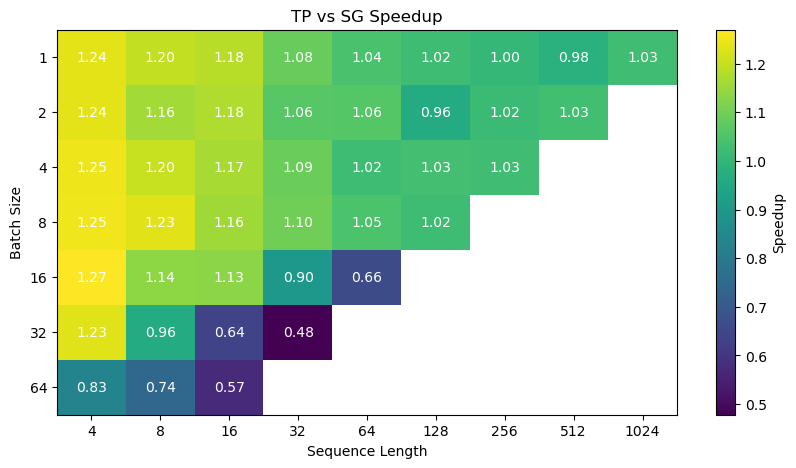

In [23]:
# Create pivot table for heatmap
heatmap_data = merged_df.pivot(
    index="batch_size",
    columns="sequence_length",
    values="speedup"
)

# Plot
plt.figure(figsize=(10, 5))

im = plt.imshow(heatmap_data, aspect="auto")

# Axis labels
plt.xlabel("Sequence Length")
plt.ylabel("Batch Size")
plt.title("TP vs SG Speedup")

# Tick labels
plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

# 🔹 Add numbers inside each cell
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        value = heatmap_data.iloc[i, j]
        plt.text(
            j, i,
            f"{value:.2f}",          # format to 2 decimal places
            ha="center",
            va="center",
            color="white"           # change to 'black' if colors are light
        )

# Color bar
plt.colorbar(im, label="Speedup")

plt.show()

In [28]:
# ---------- STEP 1: READ & PARSE ----------
def parse_log(file_path):
    rows = []

    with open(file_path, "r") as f:
        for line in f:
            parts = [p.strip() for p in line.strip().split(",")]

            # Skip empty lines
            if len(parts) < 7:
                continue

            log_type = parts[0]

            # Handle COMM logs (SSM-comm, Gate-comm)
            if "comm" in log_type:
                # Format:
                # Type, batch, seq, rank, layer, exp, start_time, end_time
                rows.append({
                    "type": log_type,
                    "batch": int(parts[1]),
                    "seq": int(parts[2]),
                    "rank": int(parts[3]),
                    "layer": int(parts[4]),
                    "exp": int(parts[5]),
                    "start": float(parts[6]),
                    "end": float(parts[7])
                })

            # Handle TOTAL logs (SSM, Gate)
            else:
                # Some rows have missing layer -> ""
                layer = parts[4] if parts[4] != "" else None

                rows.append({
                    "type": log_type,
                    "batch": int(parts[1]),
                    "seq": int(parts[2]),
                    "rank": int(parts[3]),
                    "layer": layer,
                    "exp": int(parts[5]),
                    "start": float(parts[6]),
                    "end": float(parts[7])
                })

    return pd.DataFrame(rows)


# ---------- STEP 2: TOTAL RUNTIME ----------
def compute_total_time(df):
    # Only non-comm rows
    total_df = df[~df["type"].str.contains("comm")]
    
    results = []

    for exp, group in total_df.groupby("exp"):
        min_start = group["start"].min()
        max_end = group["end"].max()
        total_time = max_end - min_start

        results.append({
            "exp": exp,
            "total_time": total_time
        })

    return pd.DataFrame(results)


# ---------- STEP 3: COMMUNICATION TIME ----------
def compute_comm_time(df):
    comm_df = df[df["type"].str.contains("comm")]
    # print(comm_df)

    results = []

    # group by experiment first
    for exp, exp_group in comm_df.groupby("exp"):

        total_comm_time = 0

        # group by layer
        for layer, layer_group in exp_group.groupby("layer"):
            min_start = layer_group["start"].min()
            max_end = layer_group["end"].max()

            layer_time = max_end - min_start
            total_comm_time += layer_time

        results.append({
            "exp": exp,
            "comm_time": total_comm_time
        })

    return pd.DataFrame(results)


# ---------- STEP 4: RUN EVERYTHING ----------
file_path = "ssm_gate_latency.log"  # change this

df = parse_log(file_path)

total_time_df = compute_total_time(df)
comm_time_df = compute_comm_time(df)

# Merge results
final_df = pd.merge(total_time_df, comm_time_df, on="exp")

print(final_df)

FileNotFoundError: [Errno 2] No such file or directory: 'ssm_gate_latency.log'

In [34]:
comm_df = df[df["type"].str.contains("comm")]

# Sort so communications from the same layer are grouped together
df_plot = (
    comm_df.sort_values(
        ["layer", "type", "rank", "start"]
    )
    .reset_index(drop=True)
)

fig = go.Figure()

for idx, row in df_plot.iterrows():
    fig.add_trace(
        go.Scatter(
            x=[row["start"], row["end"]],
            y=[idx, idx],
            mode="lines+markers",
            name=f'{row["type"]} L{int(row["layer"])} R{row["rank"]}',
            line=dict(width=6),
            hovertemplate=(
                f"Type: {row['type']}<br>"
                f"Layer: {row['layer']}<br>"
                f"Rank: {row['rank']}<br>"
                f"Start: {row['start']:.6f}<br>"
                f"End: {row['end']:.6f}<br>"
                f"Duration: {row['end'] - row['start']:.6f}"
                "<extra></extra>"
            ),
            showlegend=False,
        )
    )

fig.update_layout(
    title="Communication Timeline",
    xaxis_title="Time",
    yaxis_title="Communication Index",
    height=max(600, len(df_plot) * 12),
    hovermode="closest",
)

fig.show()